In [17]:
import pandas as pd
import numpy as np

# Učitavanje fajla pod tačnim nazivom
df = pd.read_csv('dataset/marketing_and_product_performance.csv')

# Prikaz tipova podataka i osnovnih statistika
print("Tipovi podataka:")
print(df.dtypes)

print("\nDeskriptivna statistika:")
print(df.describe())


Tipovi podataka:
Campaign_ID                              str
Product_ID                               str
Budget                               float64
Clicks                                 int64
Conversions                            int64
Revenue_Generated                    float64
ROI                                  float64
Customer_ID                              str
Subscription_Tier                        str
Subscription_Length                    int64
Flash_Sale_ID                            str
Discount_Level                         int64
Units_Sold                             int64
Bundle_ID                                str
Bundle_Price                         float64
Customer_Satisfaction_Post_Refund      int64
Common_Keywords                          str
dtype: object

Deskriptivna statistika:
             Budget        Clicks   Conversions  Revenue_Generated  \
count  10000.000000  10000.000000  10000.000000       10000.000000   
mean   25263.607524   2481.903600    4

In [18]:
# Provera varijanse (Poglavlje 10.1 - identifikacija neinformativnih kolona)
print("\nVarijansa numeričkih obeležja:")
numeric_cols = df.select_dtypes(include=[np.number])
print(numeric_cols.var())


Varijansa numeričkih obeležja:
Budget                               2.059250e+08
Clicks                               2.062020e+06
Conversions                          8.379838e+04
Revenue_Generated                    8.148571e+08
ROI                                  1.681951e+00
Subscription_Length                  1.030157e+02
Discount_Level                       2.962848e+02
Units_Sold                           3.257443e+03
Bundle_Price                         1.669748e+04
Customer_Satisfaction_Post_Refund    1.239323e+00
dtype: float64


In [19]:
import pandas as pd
import numpy as np
from scipy import stats

# 1. Priprema podataka (izbacivanje ID-jeva i enkodiranje za analizu)
df_final = df.drop(columns=['Campaign_ID', 'Product_ID', 'Customer_ID', 'Flash_Sale_ID', 'Bundle_ID', 'Common_Keywords'])
df_final['Subscription_Tier'] = df_final['Subscription_Tier'].map({'Basic': 1, 'Standard': 2, 'Premium': 3})
df_num = df_final.select_dtypes(include=[np.number])

# --- METODA 1: Z-Score (Recept 10.3 logika) ---
z_scores = np.abs(stats.zscore(df_num))
outliers_z = (z_scores > 3).any(axis=1)
print(f"Broj outlier-a (Z-score > 3): {np.sum(outliers_z)}")

# --- METODA 2: IQR (Interquartile Range) ---
Q1 = df_num.quantile(0.25)
Q3 = df_num.quantile(0.75)
IQR = Q3 - Q1
outliers_iqr = ((df_num < (Q1 - 1.5 * IQR)) | (df_num > (Q3 + 1.5 * IQR))).any(axis=1)
print(f"Broj outlier-a (IQR metoda): {np.sum(outliers_iqr)}")

# --- METODA 3: Ekstremni percentili (Top/Bottom 1%) ---
# Proveravamo koliko vrednosti upada u ekstremnih 1% na oba kraja distribucije
lower_bound = df_num.quantile(0.01)
upper_bound = df_num.quantile(0.99)
outliers_pct = ((df_num < lower_bound) | (df_num > upper_bound)).any(axis=1)
print(f"Broj redova u ekstremnim percentilima (1% i 99%): {np.sum(outliers_pct)}")

# --- FINALNI ZAKLJUČAK ZA ČIŠĆENJE ---
# Pošto su prethodne analize pokazale da su podaci uniformni, 
# ovde kreiramo df_clean koji ćemo koristiti za klasterizaciju.
df_clean = df_final.copy() 

Broj outlier-a (Z-score > 3): 0
Broj outlier-a (IQR metoda): 0
Broj redova u ekstremnim percentilima (1% i 99%): 1250


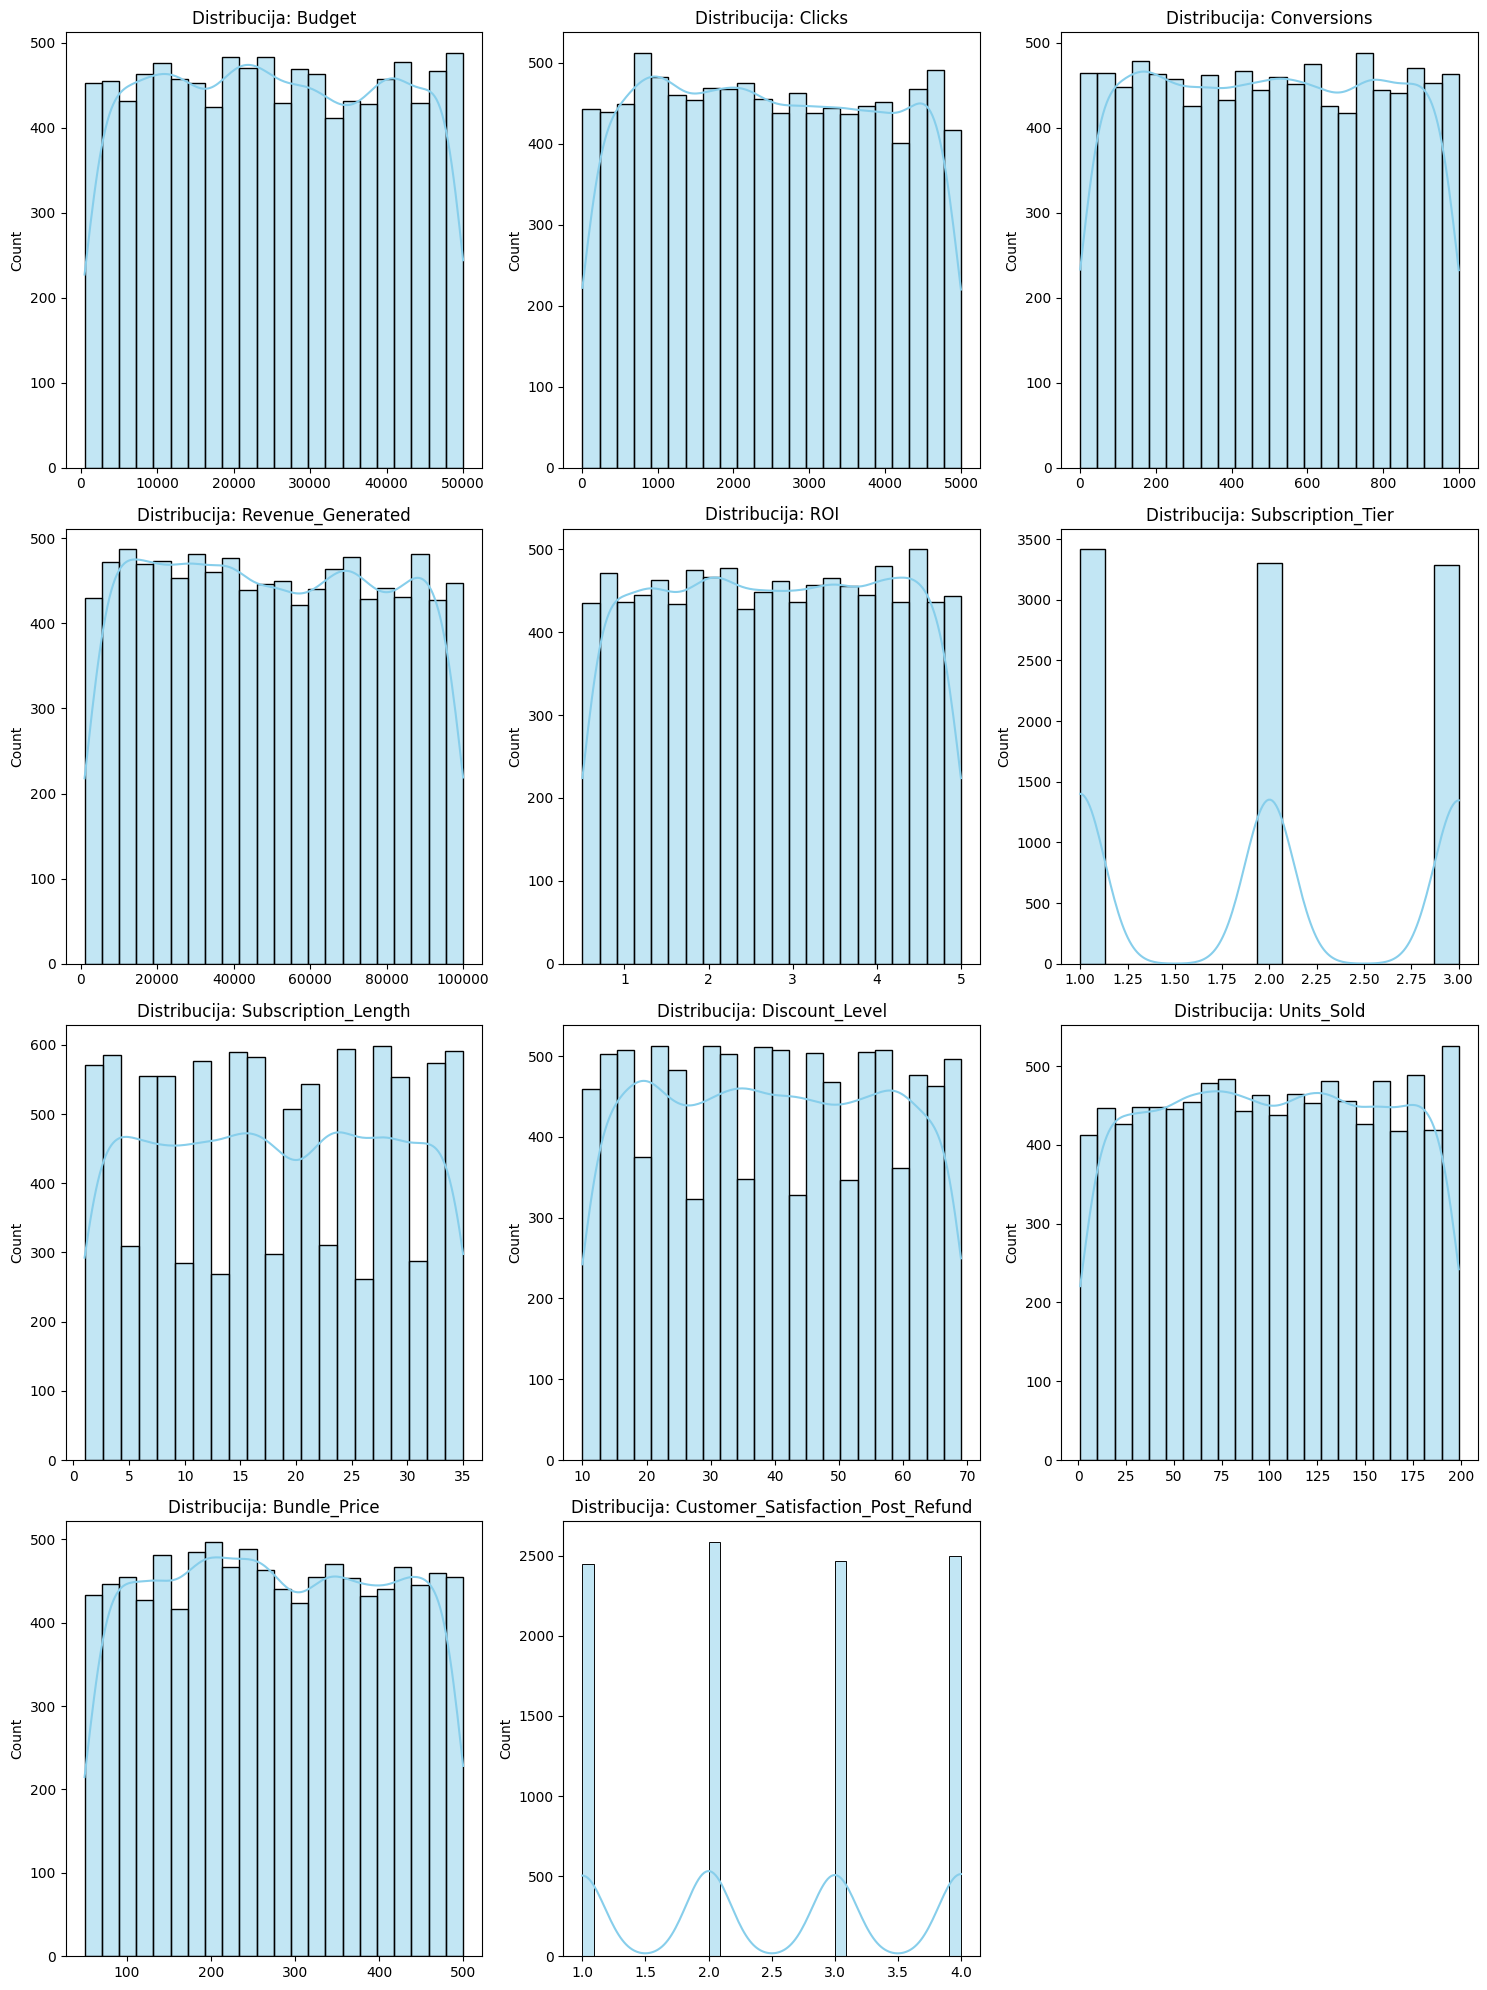

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ponovo definišemo numeričke kolone za svaki slučaj
df_num = df_clean.select_dtypes(include=[np.number])

# Vizuelizacija svih numeričkih distribucija
cols = df_num.columns
n_cols = len(cols)
fig, axes = plt.subplots(nrows=(n_cols // 3) + 1, ncols=3, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df_num[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f"Distribucija: {col}")
    axes[i].set_xlabel("")

# Uklanjanje praznih mesta u subplot mreži
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Originalni broj obeležja: 11
Broj komponenti nakon PCA (95% varijanse): 11


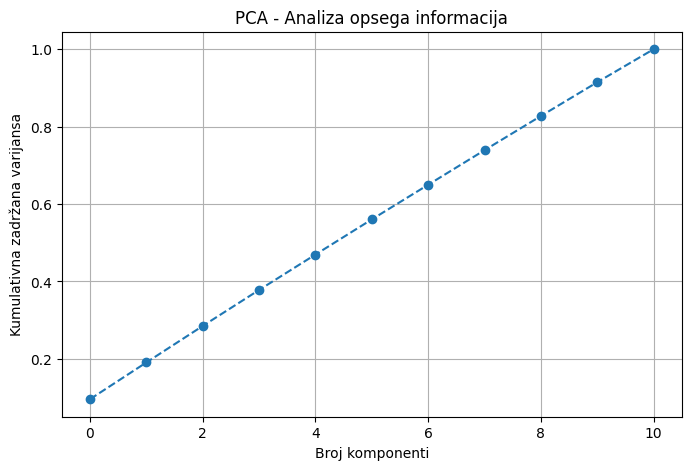

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Standardizacija (Neophodna za PCA i klasterizaciju - Recept 9.1 i 19.1)
scaler = StandardScaler()
features_std = scaler.fit_transform(df_clean.select_dtypes(include=[np.number]))

# 2. Primena PCA (Zadržavamo 95% varijanse - Recept 9.1)
pca = PCA(n_components=0.95, whiten=True)
features_pca = pca.fit_transform(features_std)

# 3. Analiza rezultata
print(f"Originalni broj obeležja: {features_std.shape[1]}")
print(f"Broj komponenti nakon PCA (95% varijanse): {features_pca.shape[1]}")

# Vizuelizacija kumulativne varijanse
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Broj komponenti')
plt.ylabel('Kumulativna zadržana varijansa')
plt.title('PCA - Analiza opsega informacija')
plt.grid(True)
plt.show()

In [22]:
from sklearn.cluster import KMeans

# 1. Inicijalizacija i treniranje modela (K=3 prema biznis logici)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
# Koristimo features_std (standardizovane podatke) jer K-Means meri rastojanja
cluster_labels = kmeans.fit_predict(features_std)

# 2. Dodavanje rezultata u originalni DataFrame (df_final ili df_clean)
df_final['Cluster'] = cluster_labels

# 3. Deskriptivna statistika za SVE numeričke kolone
numeric_cols = [
    'Budget', 'Clicks', 'Conversions', 'Revenue_Generated', 
    'ROI', 'Subscription_Length', 'Discount_Level', 
    'Units_Sold', 'Bundle_Price', 'Customer_Satisfaction_Post_Refund'
]

cluster_summary_full = df_final.groupby('Cluster')[numeric_cols].mean()

print("Kompletna analiza klastera (Prosečne vrednosti za sva obeležja):")
display(cluster_summary_full)

# 4. Provera veličine grupa
print("\nBroj zapisa po klasterima:")
print(df_final['Cluster'].value_counts())

Kompletna analiza klastera (Prosečne vrednosti za sva obeležja):


,Budget,Clicks,Conversions,Revenue_Generated,ROI,Subscription_Length,Discount_Level,Units_Sold,Bundle_Price,Customer_Satisfaction_Post_Refund
Cluster,,,,,,,,,,
0,24469.128229,2404.874663,515.139097,48902.881122,1.634418,17.915645,39.465450,99.513611,278.635474,2.483697
1,25234.683080,2442.782787,503.757611,50157.918235,2.790805,18.094555,39.068208,101.793033,276.095413,2.501756
2,26113.576726,2602.589941,477.272755,51084.386149,3.877322,18.038260,39.746992,100.739587,270.707541,2.517741



Broj zapisa po klasterima:
Cluster
1    3416
0    3343
2    3241
Name: count, dtype: int64


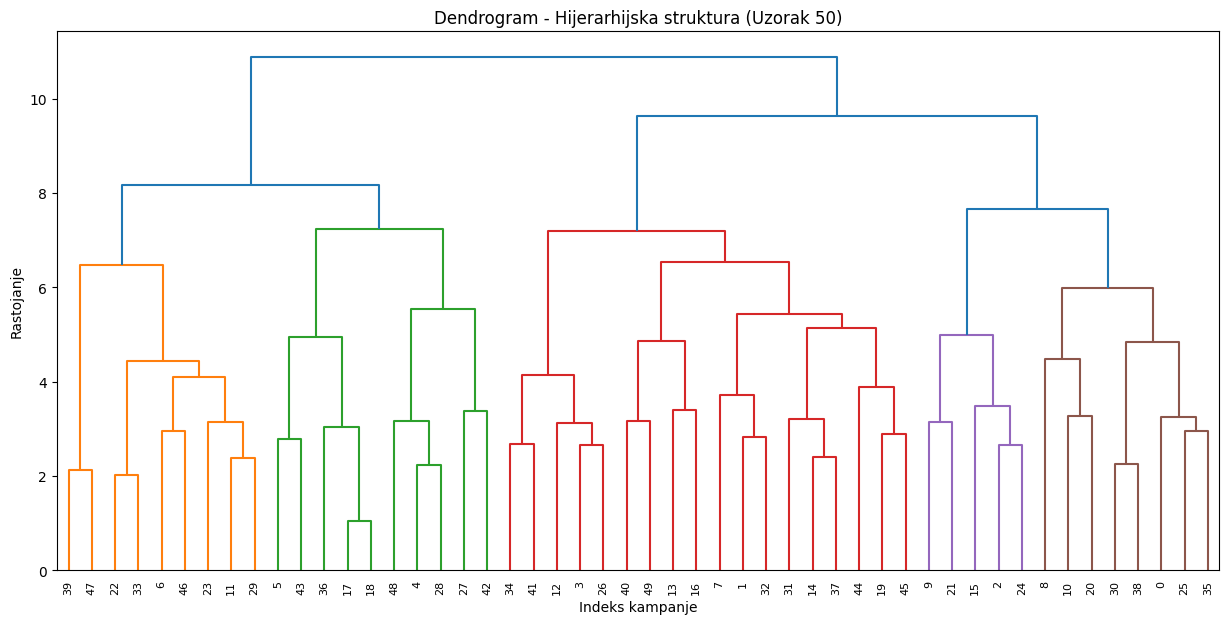

In [25]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

# Uzimamo uzorak da grafik bude čitljiv
sample_features = features_std[:50] 

plt.figure(figsize=(15, 7))
plt.title('Dendrogram - Hijerarhijska struktura (Uzorak 50)')
plt.xlabel('Indeks kampanje')
plt.ylabel('Rastojanje')

# Kreiranje drveta
dendrogram = sch.dendrogram(sch.linkage(sample_features, method='ward'))
plt.show()

In [26]:
from sklearn.cluster import AgglomerativeClustering

# Definisanje i treniranje modela
hc_model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
df_final['HC_Cluster'] = hc_model.fit_predict(features_std)

# Prikaz prvih 10 redova za upoređivanje
print("--- UPOREDNI PREGLED (K-Means vs Hijerarhijska) ---")
display(df_final[['Budget', 'Revenue_Generated', 'ROI', 'Cluster', 'HC_Cluster']].head(10))

# Statistika po HC klasterima
print("\n--- PROSECI PO HIJERARHIJSKIM KLASTERIMA ---")
hc_summary = df_final.groupby('HC_Cluster')[['Budget', 'Revenue_Generated', 'ROI', 'Units_Sold']].mean()
display(hc_summary)

--- UPOREDNI PREGLED (K-Means vs Hijerarhijska) ---


,Budget,Revenue_Generated,ROI,Cluster,HC_Cluster
0,41770.45,15520.09,1.94,0,2
1,29900.93,30866.17,0.76,0,2
2,22367.45,32585.62,1.41,1,2
3,29957.54,95740.12,3.32,2,0
4,36277.19,81990.43,3.53,2,1
5,41159.74,65792.30,0.77,1,1
6,32787.71,54205.71,4.84,1,1
7,38372.99,82083.18,0.74,0,1
8,13332.96,95260.16,0.75,0,1
9,33407.18,25569.45,2.15,1,0



--- PROSECI PO HIJERARHIJSKIM KLASTERIMA ---


,Budget,Revenue_Generated,ROI,Units_Sold
HC_Cluster,,,,
0,21012.219257,47991.127032,2.761185,109.788640
1,28418.632963,62194.588952,2.877884,100.836818
2,26585.865000,33408.770998,2.551792,86.658940


In [28]:
from sklearn.cluster import DBSCAN

# 1. Inicijalizacija DBSCAN-a
# eps: maksimalna udaljenost između dve tačke da bi se smatrale susedima
# min_samples: minimalni broj tačaka u krugu 'eps' da bi se formirao klaster
dbscan = DBSCAN(eps=0.5, min_samples=10) 

# 2. Treniranje
dbscan_labels = dbscan.fit_predict(features_std)

# 3. Dodavanje u DataFrame
df_final['DBSCAN_Cluster'] = dbscan_labels

# 4. Provera rezultata
print("Broj zapisa po DBSCAN klasterima (-1 znači šum/outlier):")
print(df_final['DBSCAN_Cluster'].value_counts())

Broj zapisa po DBSCAN klasterima (-1 znači šum/outlier):
DBSCAN_Cluster
-1    10000
Name: count, dtype: int64


In [29]:
from sklearn.cluster import MeanShift, estimate_bandwidth

# 1. Mean Shift zahteva 'bandwidth' (širinu prozora). 
# Funkcija estimate_bandwidth nam pomaže da je odredimo automatski.
bandwidth = estimate_bandwidth(features_std, quantile=0.2, n_samples=500)

# 2. Inicijalizacija i treniranje
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms_labels = ms.fit_predict(features_std)

# 3. Rezultati
df_final['MeanShift_Cluster'] = ms_labels
print("Broj klastera koje je Mean Shift pronašao:", len(pd.Series(ms_labels).unique()))
print(df_final['MeanShift_Cluster'].value_counts())

Broj klastera koje je Mean Shift pronašao: 1
MeanShift_Cluster
0    10000
Name: count, dtype: int64


In [30]:
from sklearn.cluster import MiniBatchKMeans

# 1. Pokretanje brze verzije K-Means algoritma
# batch_size određuje koliko redova gleda u jednoj iteraciji
mb_kmeans = MiniBatchKMeans(n_clusters=3, random_state=42, batch_size=100, n_init="auto")
df_final['Batch_KMeans_Cluster'] = mb_kmeans.fit_predict(features_std)

print("Mini-Batch K-Means je završen.")
# Uporedimo da li su rezultati slični običnom K-Means-u
comparison = pd.crosstab(df_final['Cluster'], df_final['Batch_KMeans_Cluster'])
print("\nMatrica poređenja (Običan vs Brzi K-Means):")
print(comparison)

Mini-Batch K-Means je završen.

Matrica poređenja (Običan vs Brzi K-Means):
Batch_KMeans_Cluster     0     1     2
Cluster                               
0                     1461  1086   796
1                     1164   602  1650
2                      580  1853   808


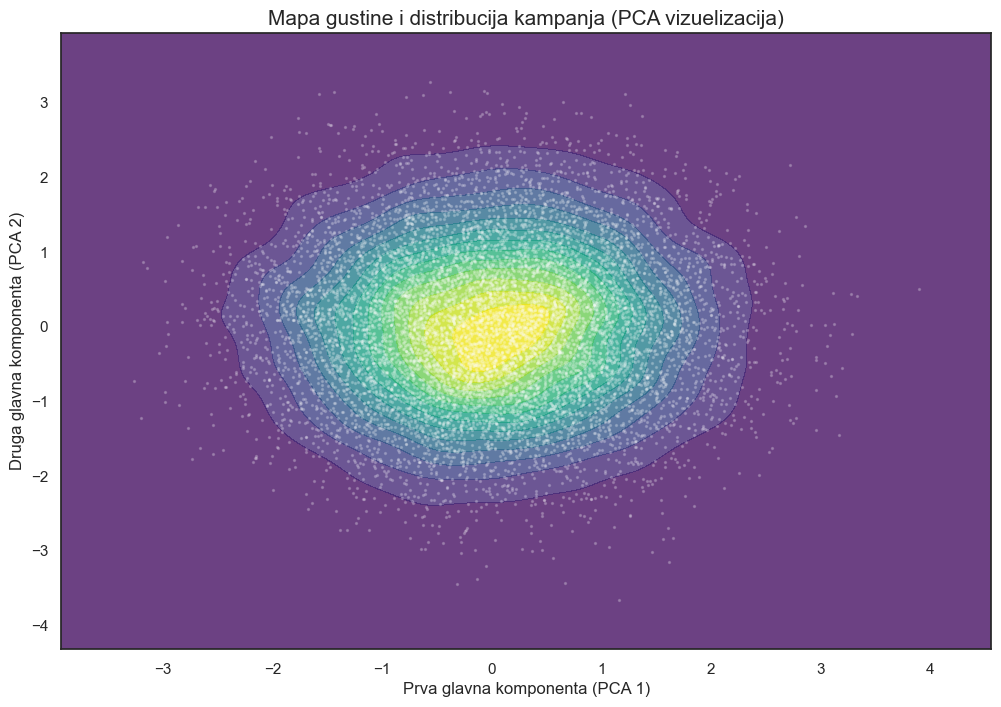

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Prvo ponovo generišemo PCA komponente (za svaki slučaj)
pca = PCA(n_components=2)
# Koristimo features_std (standardizovane podatke) koje smo definisali ranije
pca_transformed = pca.fit_transform(features_std)

# 2. Postavljamo stil i kreiramo figuru
sns.set(style="white")
plt.figure(figsize=(12, 8))

# 3. Crtamo KDE plot (gustinu - te "izohipse")
# x su podaci iz prve kolone (indeks 0), y iz druge (indeks 1)
sns.kdeplot(
    x=pca_transformed[:, 0], 
    y=pca_transformed[:, 1], 
    fill=True, 
    thresh=0, 
    levels=15, 
    cmap="viridis", 
    alpha=0.8
)

# 4. Dodajemo bele tačkice (prave podatke) preko gustine da se vidi raspored
plt.scatter(pca_transformed[:, 0], pca_transformed[:, 1], s=2, facecolor='white', alpha=0.2)

# 5. Ulepšavanje
plt.title('Mapa gustine i distribucija kampanja (PCA vizuelizacija)', fontsize=15)
plt.xlabel('Prva glavna komponenta (PCA 1)')
plt.ylabel('Druga glavna komponenta (PCA 2)')

plt.show()